In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load datasets
train_df = pd.read_csv('/content/gdrive/MyDrive/OneDrive_1_1-24-2025/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('/content/gdrive/MyDrive/OneDrive_1_1-24-2025/UNSW_NB15_testing-set.csv')
df = pd.concat([train_df, test_df], ignore_index=True)

# Preprocess
df = df.drop(['id', 'attack_cat'], axis=1)
categorical_cols = ['proto', 'service', 'state']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df = df.fillna(0)

# Split
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

# Save model and encoders
joblib.dump(model, 'nids_model.pkl')
joblib.dump(encoders, 'encoders.pkl')

# Download
from google.colab import files
files.download('nids_model.pkl')
files.download('encoders.pkl')

Accuracy: 95.23%
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     18613
           1       0.96      0.96      0.96     32922

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Accuracy: 95.23%
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     18613
           1       0.96      0.96      0.96     32922

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



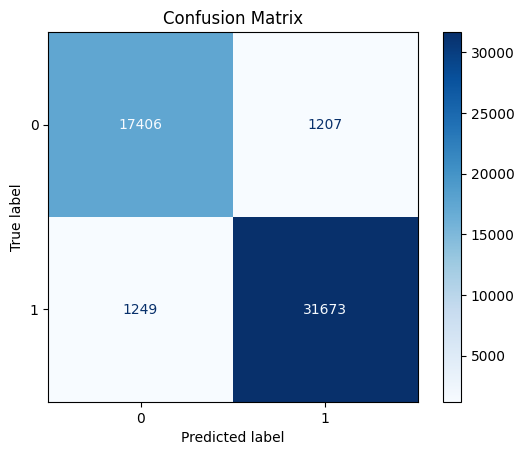

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()
